2026-01-23 13:29:40.434791: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-23 13:29:42.858825: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


CURRENT CONFIGURATION

Cosmology:
  Omega_m      = 0.315
  Omega_b      = 0.05
  h            = 0.67
  n_s          = 0.96
  sigma8       = 0.83
  M_nu         = 0.0
  w0           = -1.0
  wa           = 0.0
  aexp         = 1.0

Transfer Function: boltzmann_camb
Redshift range: [0.01, 3.0] with 500 points
Multipole range: [10, 2000] with 50 points

Galaxy bias: b0=2.0, β=0.5
f(R) models: logfR0 = [4, 5, 6]
Initializing pyccl cosmology...
Using transfer function: boltzmann_camb
Initializing Bacco emulator for GR matter power spectrum...
Initializing e-MANTIS emulator for f(R) boost factors...
Pre-computing redshift-dependent quantities (z ∈ [0.01, 3.0])...
GROWTH FACTOR VALIDATION
D(0) = 1.0000000000
✓ D(0) = 1.0 (correctly normalized)
✓ All D(z) > 0 (physically valid)
✓ D(z) decreases with z (physically correct)
  Decreasing: 499/499 points (100.0%)
✓ Growth factor values reasonable: D(z_max) = 0.315540


Computing angular power spectra for GR...
Warning [C_ℓ^gg, ℓ=10]: 443/500 k-val

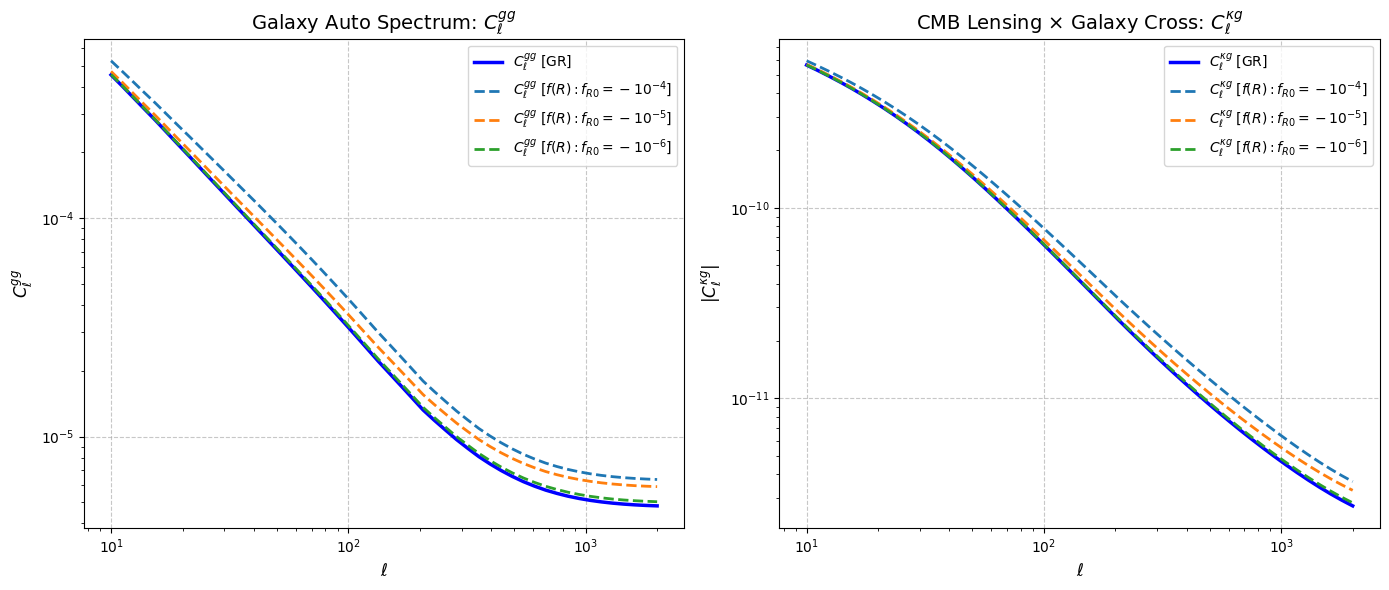


DIAGNOSTIC INFORMATION & VALIDATION
Redshift range: 0.01 to 3.00 (500 points)
Wavenumber range: 1.0000e-02 to 4.9032 Mpc⁻¹
Multipole range: 10.0 to 2000.0

Cosmological Parameters:
  Ω_m = 0.315
  Ω_Λ = 0.685
  H_0 = 67.00 km/s/Mpc
  h   = 0.67

Growth Factor Evolution (pyccl):
  D(z=0.0) = 1.0000000000 (target: 1.0000000000)
  D(z=1.0) = 0.605566
  D(z_max) = 0.315540

Galaxy Bias Evolution (β=0.5, b₀=2.0):
  b(z=0.0) = 2.0000
  b(z=1.0) ≈ 2.5701
  b(z_max) ≈ 3.5604
  (Realistic moderate evolution, matches BOSS/eBOSS observations)

Cℓ Amplitude Checks:
  C_ℓ^gg(GR) at ℓ=10:   4.5345e-04
  C_ℓ^gg(GR) at ℓ=1000: 4.8133e-06
  C_ℓ^κg(GR) at ℓ=10:   5.6128e-10
  C_ℓ^κg(GR) at ℓ=1000: 2.7294e-12

CODE VALIDATION SUMMARY
✓ Growth factor normalized to D(0) = 1.0 (from pyccl)
✓ All growth factors positive and physically valid
✓ Growth factors DECREASE with increasing z (correct physics)
✓ Power spectrum properly scaled: P(k,z) = P(k,0) × [D(z)/D(0)]²
✓ Galaxy bias uses realistic evolution: β 

In [1]:
"""
Galaxy & CMB Lensing Power Spectra: GR vs f(R) Gravity
=======================================================
Author: Adrita Khan
Date: 16 Jan 2026

Main analysis script for computing and comparing angular power spectra
in General Relativity and f(R) modified gravity theories.
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import pyccl as ccl

# Import custom utilities
from cosmology_utils import (
    comoving_distance, hubble_parameter, growth_factor, validate_growth_factor
)
from galaxy_lensing_utils import (
    normalized_galaxy_distribution, cmb_lensing_kernel
)
from power_spectrum_utils import (
    initialize_bacco_emulator, initialize_emantis_emulator,
    compute_fR_boost, create_power_spectrum_interpolator
)
from angular_power_spectrum import (
    compute_Cl_galaxy_auto, compute_Cl_galaxy_cmb_cross
)
from plotting_utils import plot_power_spectra, print_diagnostics

# Suppress warnings
warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)


# ========================================================
# Configuration
# ========================================================

# Import configuration
from config import (
    COSMO_PARAMS, C_LIGHT, Z_MIN, Z_MAX, N_Z, Z0_GALAXY,
    ELL_MIN, ELL_MAX, N_ELL, FR_VALUES, BIAS_B0, BIAS_BETA,
    K_MIN_SAFETY, K_MAX_SAFETY, TRANSFER_FUNCTION, print_config
)

# Display configuration
print_config()

# Derived quantities
H0 = COSMO_PARAMS["h"] * 100.0  # Hubble constant in km/s/Mpc
Om_m = COSMO_PARAMS["Omega_m"]


# ========================================================
# Initialize Cosmology
# ========================================================

print("Initializing pyccl cosmology...")
print(f"Using transfer function: {TRANSFER_FUNCTION}")
cosmo_ccl = ccl.Cosmology(
    Omega_c=COSMO_PARAMS["Omega_m"] - COSMO_PARAMS["Omega_b"],
    Omega_b=COSMO_PARAMS["Omega_b"],
    h=COSMO_PARAMS["h"],
    sigma8=COSMO_PARAMS["sigma8"],
    n_s=COSMO_PARAMS["n_s"],
    w0=COSMO_PARAMS["w0"],
    wa=COSMO_PARAMS["wa"],
    m_nu=COSMO_PARAMS["M_nu"],
    transfer_function=TRANSFER_FUNCTION
)


# ========================================================
# Compute Matter Power Spectra
# ========================================================

print("Initializing Bacco emulator for GR matter power spectrum...")
k, pk_nl_gr, Q_boost = initialize_bacco_emulator(COSMO_PARAMS)
pk_interp_gr = create_power_spectrum_interpolator(k, pk_nl_gr)

print("Initializing e-MANTIS emulator for f(R) boost factors...")
emantis_emu = initialize_emantis_emulator()


# ========================================================
# Pre-compute Redshift-Dependent Quantities
# ========================================================

print(f"Pre-computing redshift-dependent quantities (z ∈ [{Z_MIN}, {Z_MAX}])...")
z_grid = np.linspace(Z_MIN, Z_MAX, N_Z)

# Galaxy distribution
dNdz = normalized_galaxy_distribution(z_grid, z0=Z0_GALAXY)

# Cosmological evolution
chi_vals = comoving_distance(z_grid, cosmo_ccl)
H_vals = hubble_parameter(z_grid, cosmo_ccl, H0)

# Growth factors
D_vals = growth_factor(z_grid, cosmo_ccl)
D0 = growth_factor(0.0, cosmo_ccl)

# CMB lensing kernel
Wkappa_vals = cmb_lensing_kernel(
    z_grid, cosmo_ccl, chi_vals, Om_m, H0, C_LIGHT
)


# ========================================================
# Validate Growth Factors
# ========================================================

validation_results = validate_growth_factor(z_grid, D_vals, D0)


# ========================================================
# Compute Angular Power Spectra for GR
# ========================================================

print("\nComputing angular power spectra for GR...")
ell = np.logspace(np.log10(ELL_MIN), np.log10(ELL_MAX), N_ELL)

# Safe k bounds for interpolation
k_min_safe = k.min() * K_MIN_SAFETY
k_max_safe = k.max() * K_MAX_SAFETY

Cl_gg_gr = compute_Cl_galaxy_auto(
    ell, pk_interp_gr, cosmo_ccl, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, C_LIGHT,
    b0=BIAS_B0, beta=BIAS_BETA,
    k_min=k_min_safe, k_max=k_max_safe
)

Cl_kg_gr = compute_Cl_galaxy_cmb_cross(
    ell, pk_interp_gr, cosmo_ccl, z_grid, dNdz,
    chi_vals, H_vals, D_vals, D0, Wkappa_vals, C_LIGHT,
    b0=BIAS_B0, beta=BIAS_BETA,
    k_min=k_min_safe, k_max=k_max_safe
)


# ========================================================
# Compute Angular Power Spectra for f(R) Gravity
# ========================================================

fr_results = {"gg": {}, "kg": {}}

for logfR0_val in FR_VALUES:
    print(f"\nComputing angular power spectra for f(R) with logfR0 = {logfR0_val}...")
    
    # Compute f(R) boost and power spectrum
    pk_boost = compute_fR_boost(
        emantis_emu, COSMO_PARAMS, logfR0_val, k, aexp=COSMO_PARAMS["aexp"]
    )
    pk_fR = pk_nl_gr * pk_boost
    pk_interp_fr = create_power_spectrum_interpolator(k, pk_fR)
    
    # Compute angular power spectra
    Cl_gg_fr = compute_Cl_galaxy_auto(
        ell, pk_interp_fr, cosmo_ccl, z_grid, dNdz,
        chi_vals, H_vals, D_vals, D0, C_LIGHT,
        b0=BIAS_B0, beta=BIAS_BETA,
        k_min=k_min_safe, k_max=k_max_safe
    )
    
    Cl_kg_fr = compute_Cl_galaxy_cmb_cross(
        ell, pk_interp_fr, cosmo_ccl, z_grid, dNdz,
        chi_vals, H_vals, D_vals, D0, Wkappa_vals, C_LIGHT,
        b0=BIAS_B0, beta=BIAS_BETA,
        k_min=k_min_safe, k_max=k_max_safe
    )
    
    # Store results
    fr_results["gg"][logfR0_val] = Cl_gg_fr
    fr_results["kg"][logfR0_val] = Cl_kg_fr


# ========================================================
# Plot Results
# ========================================================

print("\nPlotting results...")
fig = plot_power_spectra(
    ell, Cl_gg_gr, Cl_kg_gr, 
    fr_results=fr_results, 
    fR_values=FR_VALUES
)
plt.show()


# ========================================================
# Print Diagnostics
# ========================================================

print_diagnostics(
    z_grid, k, ell, COSMO_PARAMS, D0, D_vals, Cl_gg_gr, Cl_kg_gr
)

print("\nAnalysis complete!")


Plotting ratio plots (f(R)/GR)...


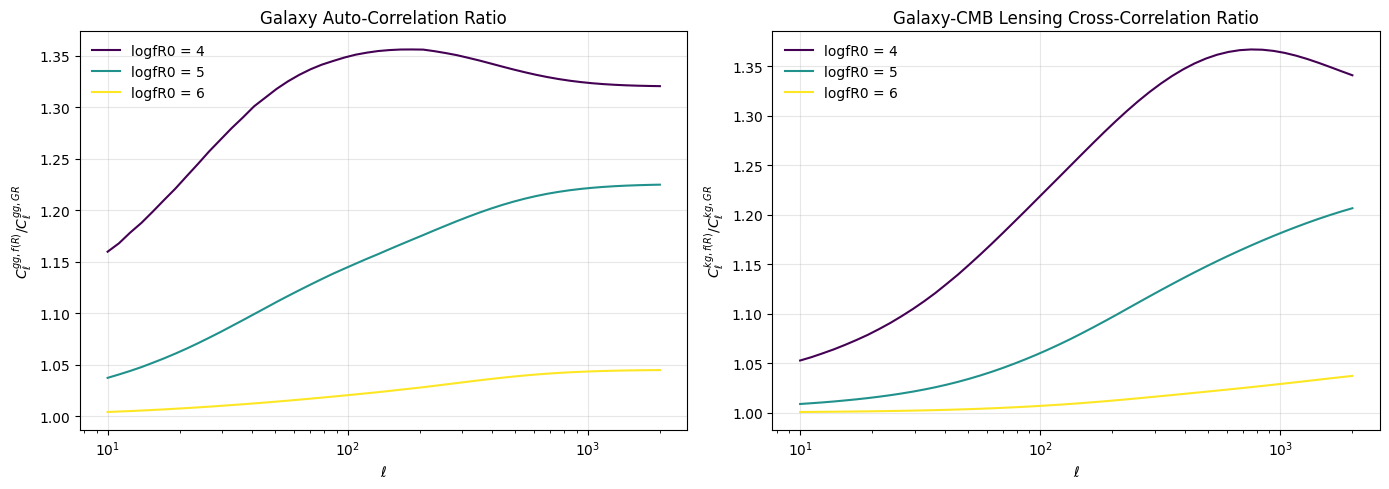

In [2]:
# ========================================================
# Ratio Plots: f(R) / GR
# ========================================================

print("\nPlotting ratio plots (f(R)/GR)...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

colors = plt.cm.viridis(np.linspace(0, 1, len(FR_VALUES)))

# Galaxy auto-correlation ratio
for i, logfR0_val in enumerate(FR_VALUES):
    Cl_ratio_gg = fr_results["gg"][logfR0_val] / Cl_gg_gr
    axes[0].plot(
        ell, Cl_ratio_gg, label=f"logfR0 = {logfR0_val}", color=colors[i]
    )
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\ell$")
axes[0].set_ylabel(r"$C_\ell^{gg, f(R)} / C_\ell^{gg, GR}$")
axes[0].set_title("Galaxy Auto-Correlation Ratio")
axes[0].grid(True, alpha=0.3)
axes[0].legend(frameon=False)

# Galaxy-CMB lensing cross-correlation ratio
for i, logfR0_val in enumerate(FR_VALUES):
    Cl_ratio_kg = fr_results["kg"][logfR0_val] / Cl_kg_gr
    axes[1].plot(
        ell, Cl_ratio_kg, label=f"logfR0 = {logfR0_val}", color=colors[i]
    )
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$\ell$")
axes[1].set_ylabel(r"$C_\ell^{kg, f(R)} / C_\ell^{kg, GR}$")
axes[1].set_title("Galaxy-CMB Lensing Cross-Correlation Ratio")
axes[1].grid(True, alpha=0.3)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

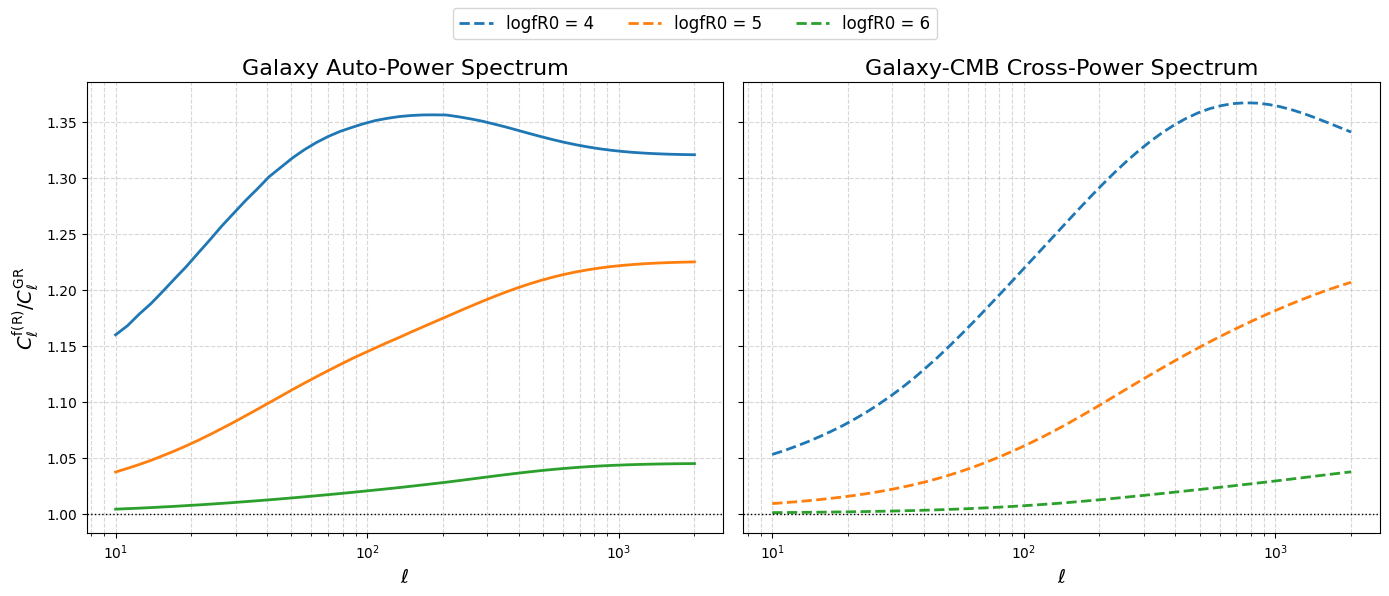

In [4]:
# ========================================================
# Enhanced Ratio Plots: f(R) / GR
# ========================================================

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Color cycle for different f(R) models
colors = list(mcolors.TABLEAU_COLORS.values())  # easy-to-read colors

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for i, logfR0_val in enumerate(FR_VALUES):
    color = colors[i % len(colors)]
    
    # Galaxy auto-power spectrum ratio
    Cl_ratio_gg = fr_results["gg"][logfR0_val] / Cl_gg_gr
    axes[0].plot(ell, Cl_ratio_gg, color=color, lw=2,
                 label=f"logfR0 = {logfR0_val}")
    
    # Galaxy-CMB cross-power spectrum ratio
    Cl_ratio_kg = fr_results["kg"][logfR0_val] / Cl_kg_gr
    axes[1].plot(ell, Cl_ratio_kg, color=color, lw=2, linestyle='--',
                 label=f"logfR0 = {logfR0_val}")

# Formatting for gg subplot
axes[0].set_xscale('log')
axes[0].axhline(1.0, color='black', linestyle=':', linewidth=1)
axes[0].set_xlabel(r'$\ell$', fontsize=14)
axes[0].set_ylabel(r'$C_\ell^{\rm f(R)} / C_\ell^{\rm GR}$', fontsize=14)
axes[0].set_title('Galaxy Auto-Power Spectrum', fontsize=16)
axes[0].grid(True, which='both', linestyle='--', alpha=0.5)

# Formatting for kg subplot
axes[1].set_xscale('log')
axes[1].axhline(1.0, color='black', linestyle=':', linewidth=1)
axes[1].set_xlabel(r'$\ell$', fontsize=14)
axes[1].set_title('Galaxy-CMB Cross-Power Spectrum', fontsize=16)
axes[1].grid(True, which='both', linestyle='--', alpha=0.5)

# Shared legend
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(FR_VALUES), fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()